# Support Vector Machine (SVM) for Shopping Preference Prediction

In this notebook we explore Support Vector Machines (SVM), one of the most powerful supervised learning algorithms used for classification and regression.

Our goal is to predict the shopping preference of customers:
- Online
- Store
- Hybrid

using behavioral and purchasing features.

This notebook covers:
1. Mathematical intuition of SVM
2. Margin maximization
3. Kernel trick
4. Bias–variance characteristics
5. When to use KNN
6. When not to use KNN
7. Hyperparameter tuning
8. Model evaluation

We integrate the project’s modular machine learning pipeline:
- src.data_loader.py
- src.features.py
- src.preprocess.py

In [46]:
# Setup
import sys
sys.path.append("..")

# Import 
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# project modules
from src.data_loader import load_raw_data
from src.preprocess import preprocess_dataset

sns.set(style="whitegrid")

## Load the Dataset

We load the dataset using the project's centralized data loader.

In [47]:
dataset_name = "online vs store shopping dataset.csv"

df = load_raw_data(dataset_name)

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## Data Preprocessing

The preprocessing pipeline performs:

- Feature engineering
- Handling categorical variables
- Feature scaling
- Train/test split

In [48]:
X_train, X_test, y_train, y_test, preprocessor = preprocess_dataset(
    df,
    target_column="shopping_preference"
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9431, 34)
Test shape: (2358, 34)


## Encode Target Variable

SVM works with **numeric labels**, so we encode the target variable.

In [49]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Mathematical Intuition of Support Vector Machines

Support Vector Machines aim to find the **optimal decision boundary** that separates classes with the **maximum margin**.

A margin is the distance between the decision boundary and the closest training samples.

Those closest samples are called **Support Vectors**.

The optimization objective:

maximize margin = 2 / ||w||

subject to:

yi (w · xi + b) ≥ 1

Where:

w = weight vector  
b = bias  
xi = training sample  
yi = label

Maximizing the margin improves **generalization**.

# Kernel Trick

Real-world datasets are rarely linearly separable.

SVM uses **kernels** to transform data into higher dimensions where separation becomes easier.

Common kernels:

| Kernel | Use Case |
|------|------|
| Linear | linearly separable data |
| Polynomial | moderate nonlinear relationships |
| RBF (Radial Basis Function) | complex nonlinear patterns |

The **RBF kernel** is the most commonly used in practice.

# Bias vs Variance

SVM behavior is controlled mainly by **C** and **gamma**.

C (Regularization):

Small C  
→ larger margin  
→ higher bias

Large C  
→ smaller margin  
→ lower bias but risk of overfitting

Gamma (for RBF kernel):

Small gamma  
→ smoother decision boundary

Large gamma  
→ more complex boundary

# When to Use Support Vector Machines (SVM)

Support Vector Machines are particularly effective in situations where the dataset has clear class boundaries and complex feature relationships.

SVM performs well when:

✔ **High-dimensional datasets**  
SVM works very well when the number of features is large compared to the number of samples.

✔ **Clear margin of separation**  
If classes can be separated with a well-defined boundary, SVM can achieve excellent performance.

✔ **Nonlinear relationships between features**  
Using kernel functions (such as RBF or polynomial kernels), SVM can model complex nonlinear decision boundaries.

✔ **Medium-sized datasets**  
SVM performs best when the dataset is not extremely large but still contains meaningful patterns.

✔ **Robust classification problems**  
Because SVM maximizes the margin between classes, it tends to generalize well and avoid overfitting.

Typical applications include:

- Text classification
- Image recognition
- Bioinformatics classification problems
- Customer segmentation and behavioral prediction

# When NOT to Use Support Vector Machines (SVM)

Despite their strong theoretical foundation, SVM models are not always the best choice.

SVM may struggle in the following scenarios:

❌ **Very large datasets**  
Training SVM models becomes computationally expensive as the number of samples grows, especially with nonlinear kernels.

❌ **Datasets with significant noise or overlapping classes**  
When class boundaries are highly ambiguous, SVM may struggle to find a stable margin.

❌ **When model interpretability is important**  
Unlike Logistic Regression or Decision Trees, SVM models are harder to interpret and explain.

❌ **Datasets with many irrelevant features**  
Although SVM handles high-dimensional spaces well, too many irrelevant features can still degrade performance.

❌ **Real-time or low-latency prediction systems**  
For very large training sets, prediction time can become slower compared to simpler models.

In such cases, alternative models such as **Logistic Regression, Random Forests, or Gradient Boosting** may provide better scalability and interpretability.

## Training a Baseline SVM Model

In [50]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_model.fit(X_train, y_train_enc)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [51]:
pred_enc = svm_model.predict(X_test)

pred = le.inverse_transform(pred_enc)

## Model Evaluation

In [52]:
print("Accuracy:", accuracy_score(y_test, pred))

print("F1 Score:", f1_score(y_test, pred, average="weighted"))

print("\nClassification Report:\n")

print(classification_report(y_test, pred))

Accuracy: 0.9575911789652247
F1 Score: 0.9422833095969771

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.00      0.00      0.00        74
      Online       0.92      0.89      0.90       235
       Store       0.96      1.00      0.98      2049

    accuracy                           0.96      2358
   macro avg       0.63      0.63      0.63      2358
weighted avg       0.93      0.96      0.94      2358



## Confusion Matrix

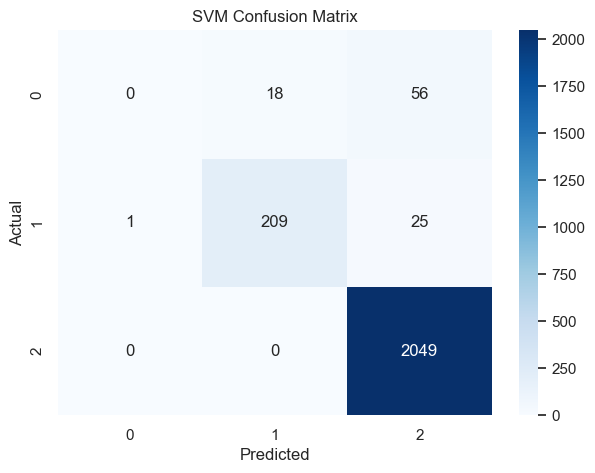

In [53]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()

# Hyperparameter Tuning with GridSearchCV

Important parameters for SVM:

| Parameter | Meaning |
|------|------|
| C | Regularization strength |
| kernel | Type of decision boundary |
| gamma | Kernel coefficient |

In [54]:
param_grid = {
    "C": [0.1, 1, 10, 50],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train_enc)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 50, 'gamma': 'scale', 'kernel': 'linear'}


In [55]:
best_svm = grid.best_estimator_

pred_enc = best_svm.predict(X_test)

pred = le.inverse_transform(pred_enc)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      Hybrid       0.94      0.97      0.95        74
      Online       1.00      0.99      0.99       235
       Store       1.00      1.00      1.00      2049

    accuracy                           1.00      2358
   macro avg       0.98      0.99      0.98      2358
weighted avg       1.00      1.00      1.00      2358



# Interpreting the Model

Unlike Logistic Regression or Decision Trees, SVM models are **less interpretable**.

However, they are excellent at capturing **complex nonlinear relationships** between features.

In our shopping dataset, important signals likely include:

- online order ratio
- online spend ratio
- digital engagement
- discount sensitivity

# Advantages

✔ Effective in high-dimensional spaces  
✔ Works well with nonlinear boundaries  
✔ Strong theoretical foundation  
✔ Good generalization performance

# Limitations

❌ Computationally expensive on large datasets  
❌ Harder to interpret  
❌ Sensitive to parameter tuning

# Model Comparison

| Model | Strength |
|------|------|
| Logistic Regression | fast, interpretable |
| KNN | captures local patterns |
| SVM | strong nonlinear classification |

# Next Models to Explore

Next models in our ML pipeline:

- Decision Trees
- Random Forest
- Gradient Boosting
- Naive Bayes

These ensemble methods often outperform single models.